# Land BGC spin-up stability — Full-CPL spin-up + piControl

Figures:
* `FullCPL_piControl_land_spinup.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os
import re
import string
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import MultipleLocator
try:
    import cftime
except ImportError:
    cftime = None

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.land_bgc import LandCtrlStability

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/land_ctrl"
DATA_DIR     = f"{OUTPUT_ROOT}/data/land"                  # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_ctrl
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_ctrl


## 1 Land spin-up trends
### Settings

In [4]:
# --- Paths ---
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
land_file   = f"{OUTPUT_ROOT}/data/land_mask/landmask.nc"
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# --- Experiment metadata ---
exp_type   = "spin-up"  # not used programmatically; just context
exp_tags   = ["Full-CPL", "piControl", "AltBG1", "AltBG2"]
labels     = ["FC", "piControl", "FC-FOSI-S1", "FC-FOSI-S2"]
time_strs  = ["0001-0501", "0001-0501", "0001-0501", "0001-0501"]
calendar   = "noleap"

exp_subdirs = {
    "20231209.v3.LR.piControl-spinup.chrysalis":      "post/time_series/lnd",
    "v3.LR.piControl":                                "post/time_series/lnd",
    "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis": "post/time_series/lnd",
    "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis": "post/time_series/lnd",
}
exps = list(exp_subdirs.keys())

# --- Region & processing settings ---
region         = "Global"
region_index   = 0
annual_hist    = False           # inputs are monthly → annualize
verbose        = True
force_fromspan = True            # construct time from time_strs if missing
time_anchor    = "start"         # "start" | "middle" | "end"
month_index_correction = "shift_back_1"  # or "auto" to detect & fix

# --- Right-axis trend settings ---
use_trend       = True
trend_window    = 10             # years
trend_min_frac  = 0.8            # require 80% valid points in window

# --- Run controls ---
exp_index    = 1                 # which experiment to run
make_plots   = True
overwrite    = False
sub_period   = 1                 # subsampling period for deltas (usually 1)
legend_loc   = "lower left"
trd_ymin1    = 301.0
trd_ymax1    = 500.0
trd_ymin2    = 2301.0
trd_ymax2    = 2500.0

ax_ymin1    = 0.0
ax_ymax1    = 500.0   # left broken segment: 0–500
ax_ymin2    = 2000.0  # right broken segment: 2001–2500
ax_ymax2    = 2500.0

fontz       = 24.0
figsize     = (36, 18)

x1_step     = 200.0       # e.g., finer ticks on 0–500
x2_step     = 200.0      # coarser ticks on 2001–2500
add_xgrid   = False


### Compute & plot

Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTECOSYSC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTSOMC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TOTVEGC_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TLAI_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_GPP_processed.nc
Skip existing /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/land_bgc/20231209.v3.LR.piControl-spinup.chrysalis_TWS_processed.nc
Skip e

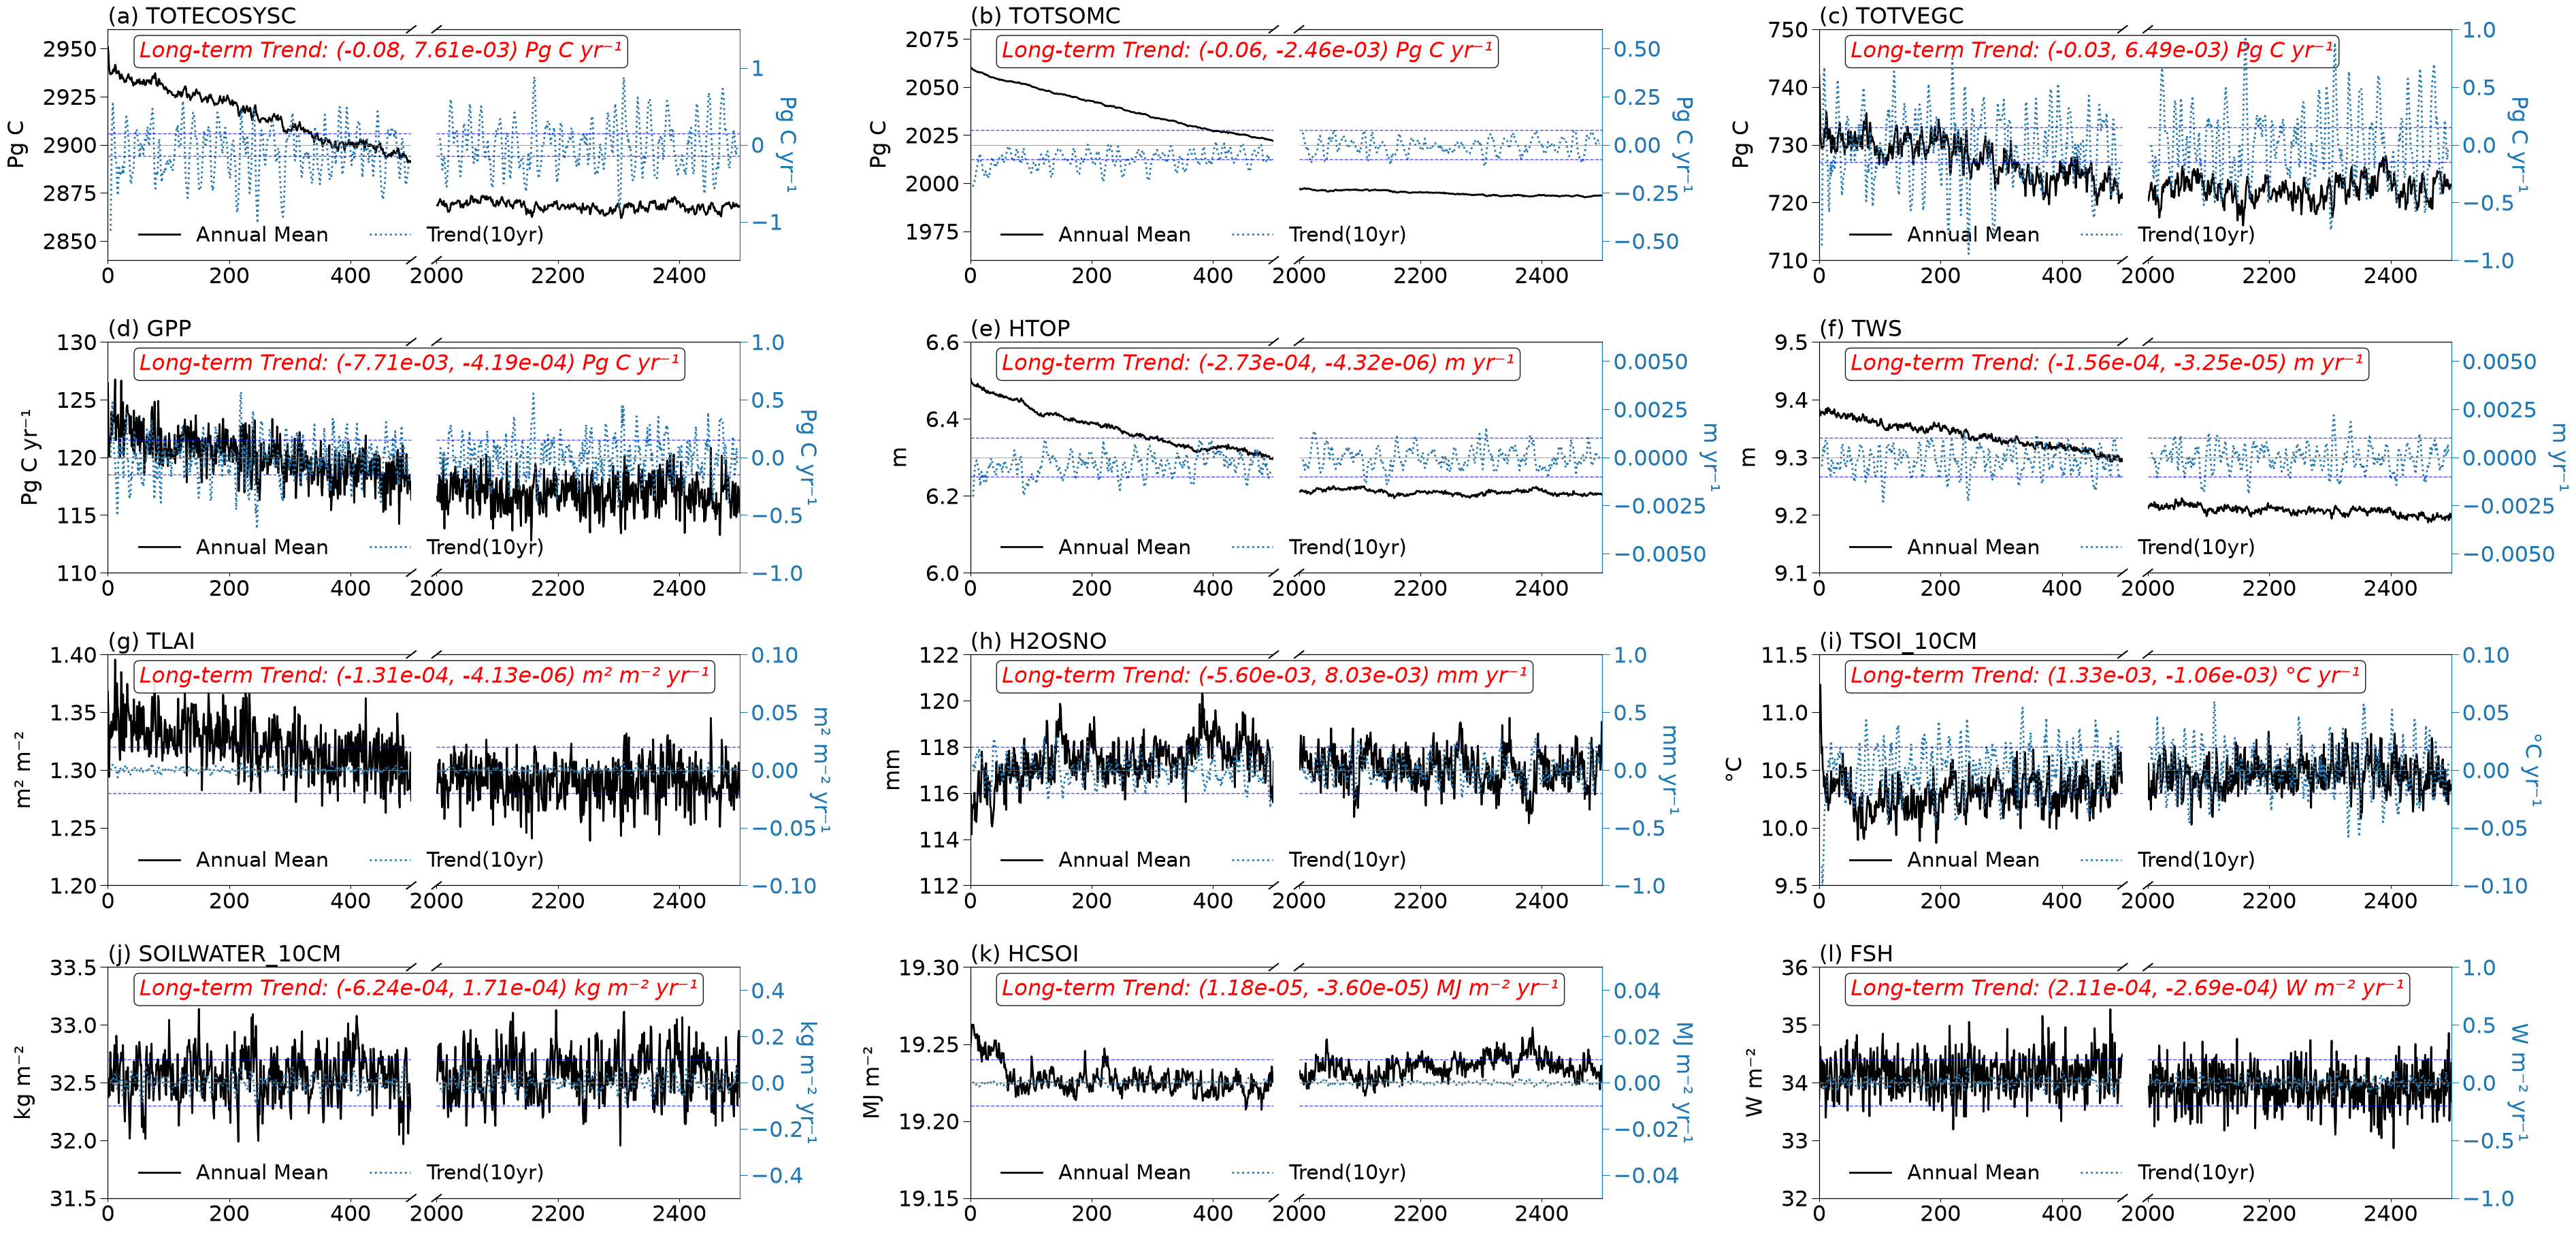

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/land_ctrl


In [5]:
# --- Instantiate tool ---
stab = LandCtrlStability(
    root_dir=data_dir,
    experiments=tuple(exps),
    case_ids=tuple(exp_tags),
    exp_labels=tuple(labels),
    time_strs=tuple(time_strs),
    exp_subdirs=exp_subdirs,
    annual_hist=annual_hist,
    verbose=verbose,
    force_time_from_span=force_fromspan,
    time_anchor=time_anchor,
    month_index_correction=month_index_correction,
    region_index=region_index,
    land_file=land_file,
    calendar=calendar,
    use_trend=use_trend,
    trend_window=trend_window,
    trend_min_frac=trend_min_frac,
)

# --- Combined Full-CPL + piControl using processed data only ---
var_dict_fullcpl = [
    ("TOTECOSYSC", (2840, 2960), (-1.5, 1.5)),
    ("TOTSOMC", (1960, 2080), (-0.6, 0.6)),
    ("TOTVEGC", (710, 750), (-1.0, 1.0)),
    ("GPP", (110, 130), (-1.0, 1.0)),
    ("HTOP", (6.0, 6.6), (-0.006, 0.006)),
    ("TWS", (9.1, 9.5), (-0.006, 0.006)),
    ("TLAI", (1.20, 1.40), (-0.1, 0.1)),
    ("H2OSNO", (112, 122), (-1.0, 1.0)),
    ("TSOI_10CM", (9.5, 11.5), (-0.1, 0.1)),
    ("SOILWATER_10CM", (31.5, 33.5), (-0.5, 0.5)),
    ("HCSOI", (19.15, 19.30), (-0.05, 0.05)),
    ("FSH", (32, 36), (-1.0, 1.0)),
]

output_pdf_combined = os.path.join(
    fig_dir, "Full-CPL_piControl_land_spinup.pdf"
)

# preprocess Full-CPL and piControl
for exp_index in [0, 1]:
    exp = exps[exp_index]
    stab.save_processed_series(
        exp=exp,
        exp_index=exp_index,
        out_dir=out_dir,
        overwrite=overwrite,
    )

stab.analyze_combined_fullcpl_picontrol(
    var_dict=var_dict_fullcpl,
    full_index=0,   # Full-CPL exp index
    pi_index=1,     # piControl exp index
    subper=sub_period,
    trd_ymin1=trd_ymin1,
    trd_ymax1=trd_ymax1,
    trd_ymin2=trd_ymin2,
    trd_ymax2=trd_ymax2,
    ax_ymin1=ax_ymin1,
    ax_ymax1=ax_ymax1,
    ax_ymin2=ax_ymin2,
    ax_ymax2=ax_ymax2,
    fontz=fontz,
    figsize=figsize,
    legend_loc=legend_loc,
    x1_step=x1_step,
    x2_step=x2_step,
    add_xgrid=add_xgrid,
    output_pdf=output_pdf_combined,
    processed_dir=out_dir,
)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
